In [1]:
from google.colab import files

uploaded = files.upload()

Saving student_mental_health_dataset.csv to student_mental_health_dataset.csv


FIRST 5 ROWS
   Age  Gender  CGPA  Academic_Pressure  Study_Satisfaction  \
0   23    Male  8.81                  1                   2   
1   20  Female  8.99                  1                   2   
2   27    Male  7.18                  2                   1   
3   24    Male  9.09                  5                   5   
4   21    Male  5.60                  4                   2   

   Sleep_Duration_Hours Dietary_Habits  Study_Hours_Per_Day  Financial_Stress  \
0                   5.6        Healthy                  9.4                 1   
1                   8.0      Unhealthy                  3.7                 3   
2                   8.4      Unhealthy                  1.4                 4   
3                   5.5       Moderate                  2.1                 2   
4                   8.3       Moderate                  9.0                 1   

  Family_History_Mental_Illness  Depression_Status  
0                           Yes                  0  
1              

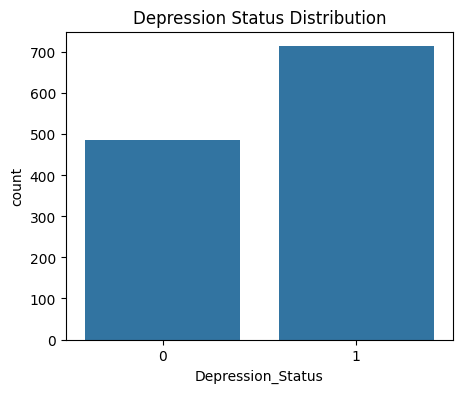

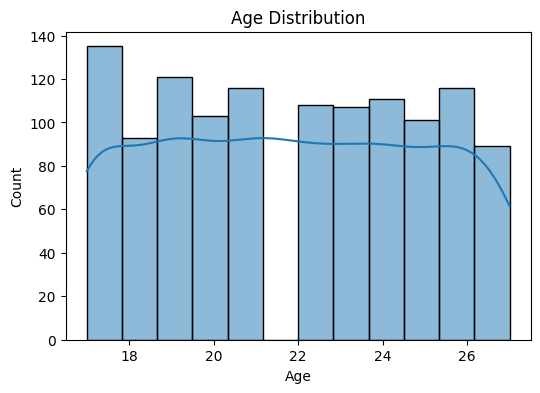

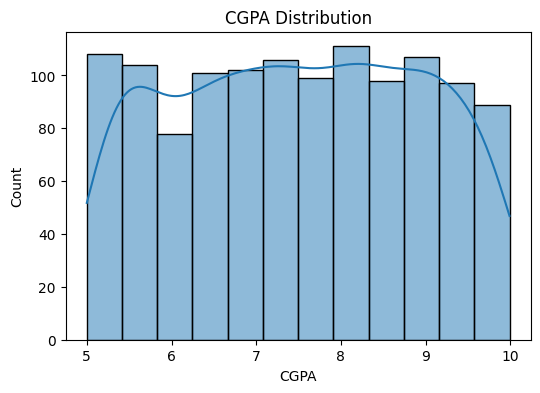


FEATURE ENGINEERING DONE

ENCODING COMPLETED


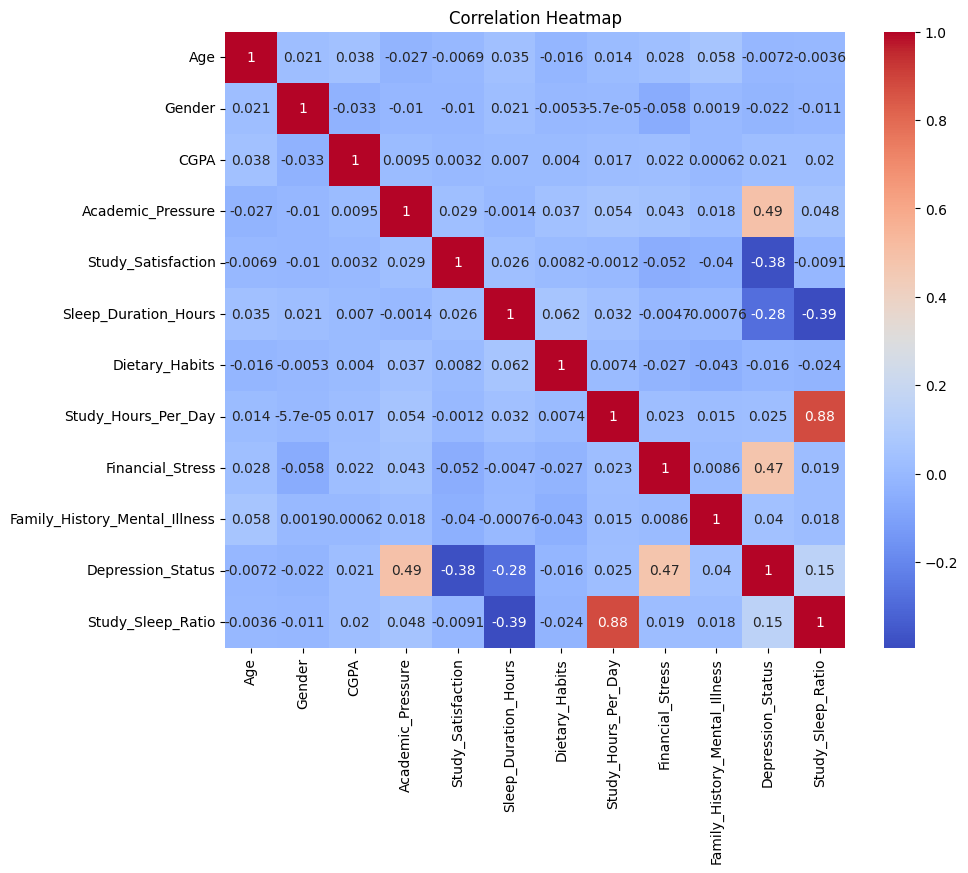


TRAIN SHAPE: (960, 11)
TEST SHAPE: (240, 11)

MODEL ACCURACIES
Logistic Regression: 0.9792
Decision Tree: 0.9125
Random Forest: 0.9458

CONFUSION MATRIX
[[ 94  10]
 [  3 133]]


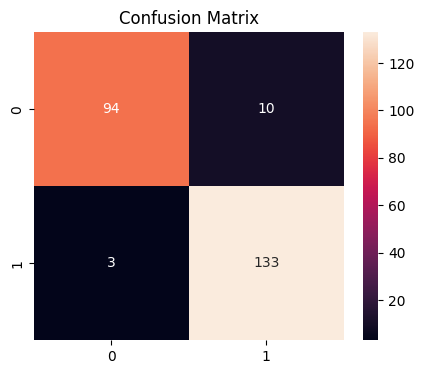


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.90      0.94       104
           1       0.93      0.98      0.95       136

    accuracy                           0.95       240
   macro avg       0.95      0.94      0.94       240
weighted avg       0.95      0.95      0.95       240


FEATURE IMPORTANCE
                          Feature  Importance
3               Academic_Pressure    0.243260
8                Financial_Stress    0.207000
4              Study_Satisfaction    0.167449
5            Sleep_Duration_Hours    0.124974
10              Study_Sleep_Ratio    0.066814
2                            CGPA    0.060056
7             Study_Hours_Per_Day    0.056235
0                             Age    0.036150
6                  Dietary_Habits    0.018048
9   Family_History_Mental_Illness    0.010723
1                          Gender    0.009293

MODEL SAVED SUCCESSFULLY


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
# ==========================
# STUDENT MENTAL HEALTH PREDICTION PROJECT
# ==========================

# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import pickle

# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("student_mental_health_dataset.csv")

print("FIRST 5 ROWS")
print(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ==========================
# MISSING VALUES
# ==========================

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================
# DUPLICATES
# ==========================

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ==========================
# EDA
# ==========================

# Depression Distribution

plt.figure(figsize=(5,4))
sns.countplot(x="Depression_Status", data=df)
plt.title("Depression Status Distribution")
plt.show()

# Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

# CGPA Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["CGPA"], kde=True)
plt.title("CGPA Distribution")
plt.show()

# ==========================
# FEATURE ENGINEERING
# ==========================

df["Study_Sleep_Ratio"] = (
    df["Study_Hours_Per_Day"] /
    df["Sleep_Duration_Hours"]
)

print("\nFEATURE ENGINEERING DONE")

# ==========================
# LABEL ENCODING
# ==========================

le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df["Dietary_Habits"] = le.fit_transform(
    df["Dietary_Habits"]
)

df["Family_History_Mental_Illness"] = le.fit_transform(
    df["Family_History_Mental_Illness"]
)

print("\nENCODING COMPLETED")

# ==========================
# CORRELATION HEATMAP
# ==========================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================
# FEATURES & TARGET
# ==========================

X = df.drop(
    "Depression_Status",
    axis=1
)

y = df["Depression_Status"]

# ==========================
# TRAIN TEST SPLIT
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAIN SHAPE:", X_train.shape)
print("TEST SHAPE:", X_test.shape)

# ==========================
# LOGISTIC REGRESSION
# ==========================

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    lr_pred
)

# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    dt_pred
)

# ==========================
# RANDOM FOREST
# ==========================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    rf_pred
)

# ==========================
# MODEL COMPARISON
# ==========================

print("\nMODEL ACCURACIES")

print(
    "Logistic Regression:",
    round(lr_acc,4)
)

print(
    "Decision Tree:",
    round(dt_acc,4)
)

print(
    "Random Forest:",
    round(rf_acc,4)
)

# ==========================
# CONFUSION MATRIX
# ==========================

cm = confusion_matrix(
    y_test,
    rf_pred
)

print("\nCONFUSION MATRIX")
print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

# ==========================
# CLASSIFICATION REPORT
# ==========================

print("\nCLASSIFICATION REPORT")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

# ==========================
# FEATURE IMPORTANCE
# ==========================

importance = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature":X.columns,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE")

print(importance_df)

# ==========================
# SAVE MODEL
# ==========================

pickle.dump(
    rf,
    open(
        "mental_health_model.pkl",
        "wb"
    )
)

print("\nMODEL SAVED SUCCESSFULLY")
